## Bank_Marketing_Preprocessing.ipynb ##

5. Data Preprocessing 

   5.1 Handling Missing Values
       - Fill missing values in job, education, contact with "unknown"
       - Fill missing values in poutcome with "not_contacted"

   5.2 Removing Data Leakage Feature
       - Drop "duration" variable

   5.3 Binary Variable Encoding
       - Convert default, housing, loan from "yes/no" to 1/0

   5.4 Feature Engineering for pdays
       - Create "previous_contact" indicator (whether contacted before)
       - Create "pdays_clean" by handling -1 values

   5.5 Outlier Handling
       - Apply IQR-based capping to "balance"

   5.6 One-Hot Encoding for Categorical Variables
       - Encode job, marital, education, contact, month, poutcome

   5.7 Feature Scaling (Normalization)
       - Apply Min-Max normalization to numerical variables

## **Load Data**

In [225]:
#!pip install ucimlrepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
import warnings
warnings.filterwarnings("ignore")
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 

# variable information 
print(bank_marketing.variables) 

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [226]:
df = pd.concat([X,y], axis = 1)

## **Exploratory Data Analysis**

In [227]:
# Dataset overview
print("Shape:", df.shape)
df.info()

Shape: (45211, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [228]:
df["y"].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

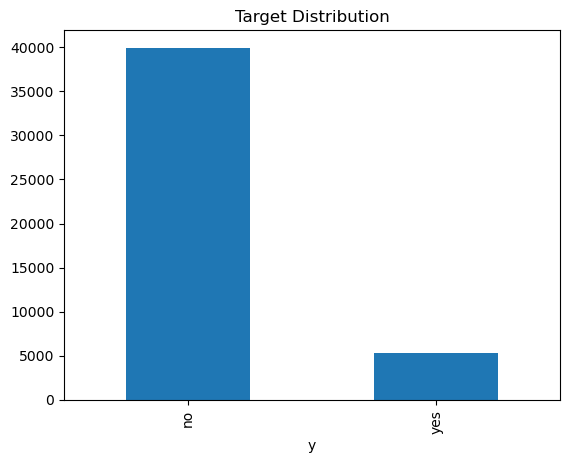

In [229]:
#Target Distribution
# indicate imbalance, need reweighting when modeling
df["y"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.show()

In [230]:
# check missing values
df.isnull().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64

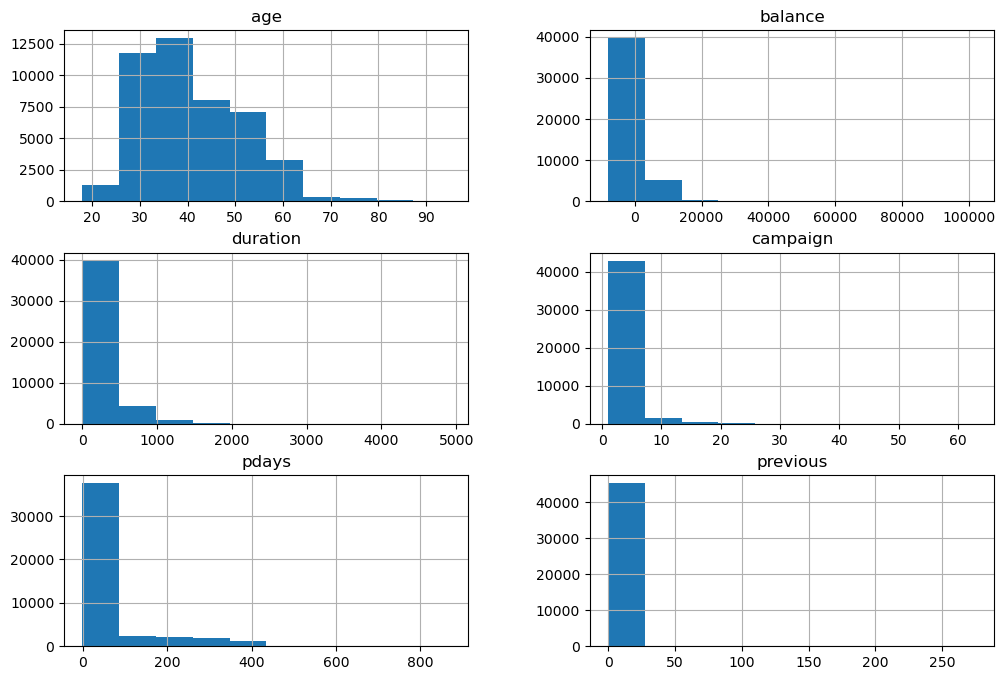

In [231]:
# distribution for numerical values
num_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]
df[num_cols].hist(figsize=(12,8), bins = 10)
plt.show()

## **Data Cleaning & Feature Engineering**

In [232]:
# 1. Handle Missing Values
df["job"] = df["job"].fillna("unknown")

df["education"] = df["education"].fillna("unknown")

df["contact"] = df["contact"].fillna("unknown")

df["poutcome"] = df["poutcome"].fillna("not_contacted")

In [233]:
# 2. Remove Leakage Feature
df = df.drop(columns=["duration"])

In [234]:
# 3. create binary target variable
df["y_binary"] = (df["y"] == "yes").astype(int)

In [235]:
# 4. other binary varibles encoding
binary_cols = ["default", "housing", "loan"]

for col in binary_cols:

    df[col] = df[col].map({"yes": 1, "no": 0})

In [236]:
# 5. number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)
print(df["pdays"].value_counts().head(10))

# Feature engineering: contacted before / or not + how many days since last contact
df["previous_contact"] = (df["pdays"] != -1).astype(int)

df["pdays_clean"] = df["pdays"].replace(-1, np.nan)
df["pdays_clean"] = df["pdays_clean"].fillna(0)

pdays
-1      36954
 182      167
 92       147
 91       126
 183      126
 181      117
 370       99
 184       85
 364       77
 95        74
Name: count, dtype: int64


We first convert -1 to NaN to separate non-contact cases from actual time values. Then we fill NaN with 0 because the model cannot handle missing values directly. The meaning is preserved by combining this feature with a binary indicator of previous contact.

In [237]:
# 6. balance outlier removal

q1 = df ['balance'].quantile(0.25)
q3 = df["balance"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5* iqr
upper = q3 + 1.5 * iqr

df["balance"] = df["balance"].clip(lower, upper)

In [238]:
# 7. one hot encoding, note: here we keep all categories for easier interpretation, when modeling, need to remvoe the baseline
cat_cols = ["job", "marital", "education", "contact", "month", "poutcome"]
df = pd.get_dummies(df, columns = cat_cols, drop_first = False)

In [239]:
# 8. min-max normalization
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    mn = df[col].min()
    mx = df[col].max()
    
    if mx > mn:
        df[col] = (df[col] - mn) / (mx - mn)

In [240]:
# check cleaned data shape
print("Final shape:", df.shape)
df.head()
df.columns.tolist()

Final shape: (45211, 51)


['age',
 'default',
 'balance',
 'housing',
 'loan',
 'day_of_week',
 'campaign',
 'pdays',
 'previous',
 'y',
 'y_binary',
 'previous_contact',
 'pdays_clean',
 'job_admin.',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_divorced',
 'marital_married',
 'marital_single',
 'education_primary',
 'education_secondary',
 'education_tertiary',
 'education_unknown',
 'contact_cellular',
 'contact_telephone',
 'contact_unknown',
 'month_apr',
 'month_aug',
 'month_dec',
 'month_feb',
 'month_jan',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep',
 'poutcome_failure',
 'poutcome_not_contacted',
 'poutcome_other',
 'poutcome_success']

In [241]:
# download cleand data
df.to_csv('cleaned_data.csv', index = False)